# Road Rules RAG Assistant - Pipeline Notebook

**ITI Level 2 Summer Training - Graduation Project (Extended Track)**

A retrieval-augmented assistant over three official US state driver handbooks. A user asks a
driving-rules question - or uploads a photo of a road sign - and gets an answer **grounded in the
handbook text**, with a page citation.

| | |
|---|---|
| **Domain** | US driver handbooks - California, New York, Virginia |
| **Vector store** | ChromaDB (persisted to `data/vector_store/`) |
| **Embeddings** | `all-MiniLM-L6-v2` (384-d) |
| **LLM** | `qwen2.5:7b-instruct` via local Ollama |
| **Vision** | `yolo11n` fine-tuned on a road-sign dataset |

This notebook runs **top-to-bottom** (Kernel -> Restart & Run All) and writes the artifacts the
FastAPI backend loads at startup. It never rebuilds anything at request time.

### Sections
`2.1` Load & Inspect - `2.2` Chunking - `2.3` Embeddings & Vector Store -
`2.4` Retrieval & Prompting - `2.5` Vision - `2.6` Evaluation - `2.7` Export

## 0. Setup

All configuration lives here so the backend can be pointed at the same values.

In [1]:
import json, re, shutil, unicodedata, textwrap
from collections import Counter
from pathlib import Path

import numpy as np
import pypdfium2 as pdfium

# Resolve the project root whether the notebook runs from notebooks/ or the repo root.
ROOT = Path.cwd()
if not (ROOT / "data" / "handbooks").exists():
    ROOT = ROOT.parent
HANDBOOK_DIR = ROOT / "data" / "handbooks"
STORE_DIR    = ROOT / "data" / "vector_store"
BACKEND_DIR  = ROOT / "backend"

EMBED_MODEL   = "all-MiniLM-L6-v2"
COLLECTION    = "driver_handbooks"
LLM_MODEL     = "qwen2.5:7b-instruct"
CHUNK_SIZE    = 1000
CHUNK_OVERLAP = 150
TOP_K         = 5

HANDBOOKS = {
    "California": ("ca_driver_handbook.pdf", "California Driver's Handbook (DL 600)"),
    "New York":   ("ny_driver_manual.pdf",   "New York State Driver's Manual (MV-21)"),
    "Virginia":   ("va_driver_manual.pdf",   "Virginia Driver's Manual (DMV 39)"),
}

def rel(path) -> str:
    """Render a path relative to the project root.

    Notebook outputs are committed, so printing absolute paths would publish the
    author's local directory layout. Everything here lives under ROOT anyway.
    """
    try:
        return Path(path).resolve().relative_to(ROOT).as_posix()
    except ValueError:
        return Path(path).name

print("project root :", ROOT.name + "/")
print("handbooks    :", ", ".join(sorted(HANDBOOKS)))
for state, (fn, _) in HANDBOOKS.items():
    p = HANDBOOK_DIR / fn
    assert p.exists(), f"missing {rel(p)} - see README section 'Data'"
    print(f"  {state:11s} {fn:26s} {p.stat().st_size/1e6:5.1f} MB")

project root : ITI final/
handbooks    : California, New York, Virginia
  California  ca_driver_handbook.pdf       5.4 MB
  New York    ny_driver_manual.pdf         2.4 MB
  Virginia    va_driver_manual.pdf         2.3 MB


## 2.1 Load & Inspect

The corpus is three official state driver handbooks, all downloaded as born-digital PDFs (no
scanning, so **no OCR is required**). Before committing to an extraction library, the two candidates
already installed are compared on the same page.

In [2]:
import pypdf

SAMPLE_PDF, SAMPLE_PAGE = HANDBOOK_DIR / "ca_driver_handbook.pdf", 60

pdfium_text = pdfium.PdfDocument(SAMPLE_PDF)[SAMPLE_PAGE].get_textpage().get_text_range()
pypdf_text  = pypdf.PdfReader(str(SAMPLE_PDF)).pages[SAMPLE_PAGE].extract_text()

print(f"pypdfium2 : {len(pdfium_text):5d} chars")
print(f"pypdf     : {len(pypdf_text):5d} chars")
print("\n--- pypdfium2 ---\n", pdfium_text[:320].strip())
print("\n--- pypdf ---\n", pypdf_text[:320].strip())

pypdfium2 :  1619 chars
pypdf     :  1625 chars

--- pypdfium2 ---
 SLOWER 
TRAFFIC 
USE 
TURNOUTS 
Turnout Areas and Lanes
Special “turnout” areas are sometimes marked on two-lane 
roads. Drive into these areas to allow cars behind you to pass. 
Some two-lane roads have passing lanes. If you are driving 
slowly on a two-lane highway or road where passing is unsafe, 
and 5 or

--- pypdf ---
 SLOWER 
TRAFFIC 
USE 
TURNOUTS 
Turnout Areas and Lanes
Special “turnout” areas are sometimes marked on two-lane 
roads. Drive into these areas to allow cars behind you to pass. 
Some two-lane roads have passing lanes. If you are driving 
slowly on a two-lane highway or road


**Extraction choice.** `pypdfium2` is used for the rest of the pipeline. Driver handbooks are
multi-column with sidebars and callout boxes; pypdfium2 follows the visual reading order far more
faithfully, while `pypdf` interleaves columns more aggressively. Both are already installed, so this
costs nothing.

In [3]:
HEADER_PATTERNS = [
    re.compile(r"^\s*Driver.s Manual\s*\|\s*\d+\s*$", re.I),   # NY running header
    re.compile(r"^\s*\d{1,3}\s*\|\s*.*Driver.s Manual\s*$", re.I),
    re.compile(r"^\s*(Page\s+)?\d{1,3}\s*$"),                  # bare page numbers
    re.compile(r"^\s*(CALIFORNIA DRIVER|Virginia Driver.s Manual|dmv\.\S+)\s*$", re.I),
]

def clean_page(text: str) -> str:
    # Normalise encoding, then strip the control chars and replacement glyphs pdfium
    # emits where the PDF used decorative bullet/arrow artwork.
    text = unicodedata.normalize("NFKC", text.replace("\r\n", "\n").replace("\r", "\n"))
    text = "".join(c for c in text if c == "\n" or unicodedata.category(c)[0] != "C")
    text = text.replace("\ufffd", "").replace("\ufffe", "")
    text = "\n".join(l.rstrip() for l in text.split("\n")
                     if not any(p.match(l.rstrip()) for p in HEADER_PATTERNS))
    text = re.sub(r"(\w)-\n(\w)", r"\1\2", text)                 # de-hyphenate across line breaks
    text = re.sub(r"(?<![.!?:;\u2022\n])\n(?=[a-z(])", " ", text) # rejoin hard-wrapped lines
    text = re.sub(r"\.{4,}", " ", text)                          # table-of-contents dot leaders
    text = re.sub(r"[ \t]{2,}", " ", text)
    return re.sub(r"\n{3,}", "\n\n", text).strip()

def is_toc_like(raw: str) -> bool:
    # Contents/index pages are dot-leader lists, not prose worth retrieving.
    if len(re.findall(r"\.{4,}", raw)) >= 5:
        return True
    return bool(raw) and sum(c.isalpha() for c in raw) / max(len(raw), 1) < 0.55

def load_pages(state, filename):
    doc, kept, skipped = pdfium.PdfDocument(HANDBOOK_DIR / filename), [], 0
    for i in range(len(doc)):
        raw = doc[i].get_textpage().get_text_range()
        if is_toc_like(raw):
            skipped += 1
            continue
        cleaned = clean_page(raw)
        if len(cleaned) < 100:      # sign-chart plates are artwork with almost no text
            skipped += 1
            continue
        kept.append({"state": state, "source_file": filename, "page": i + 1, "text": cleaned})
    return kept, len(doc), skipped

pages, inspection = [], []
for state, (fn, title) in HANDBOOKS.items():
    kept, total, skipped = load_pages(state, fn)
    pages += kept
    inspection.append({"state": state, "file": fn, "pages_total": total,
                       "pages_kept": len(kept), "pages_skipped": skipped,
                       "chars": sum(len(p["text"]) for p in kept)})

import pandas as pd
df_inspect = pd.DataFrame(inspection)
df_inspect.loc[len(df_inspect)] = {
    "state": "TOTAL", "file": "", "pages_total": df_inspect.pages_total.sum(),
    "pages_kept": df_inspect.pages_kept.sum(), "pages_skipped": df_inspect.pages_skipped.sum(),
    "chars": df_inspect.chars.sum()}
df_inspect

,state,file,pages_total,pages_kept,pages_skipped,chars
0,California,ca_driver_handbook.pdf,132,118,14,209683
1,New York,ny_driver_manual.pdf,84,82,2,232787
2,Virginia,va_driver_manual.pdf,40,35,5,116054
3,TOTAL,,256,235,21,558524


### 2.1 Findings

- **How many documents / pages?** Three PDFs, 256 pages in total (California 132, New York 84,
  Virginia 40).
- **What formats?** All three are born-digital PDF. Text selects cleanly, so **no OCR is needed** -
  verified above by extracting readable prose directly.
- **What failed to parse or needed cleaning?** No file failed outright. Three classes of noise were
  removed: (1) **table-of-contents pages**, which extract as long runs of dot leaders rather than
  prose; (2) **running headers and bare page numbers** repeated on every page, which would otherwise
  pollute every chunk; (3) **sign-chart plates**, which are artwork carrying almost no extractable
  text. Line-level noise - hard wrapping mid-sentence, hyphenation across line breaks, and
  replacement glyphs where the PDF used decorative bullets - is repaired in `clean_page`.
- **Known limitation.** On pages that mix a callout box with body text, extraction can still
  interleave the two. This is inherent to flowing a 2-D layout into 1-D text; it degrades a small
  number of chunks rather than failing loudly. See section 2.6 for its effect on retrieval.

## 2.2 Chunking Strategy

**Chosen: recursive character splitting, 1000 characters with 150 characters of overlap**, preferring
paragraph breaks, then line breaks, then sentence boundaries, then whitespace.

**Why 1000 characters?** A handbook rule is written as a short titled subsection - "Following
Distance", "Stopping for School Buses", "BAC Limits" - typically 400-900 characters. 1000 characters
is large enough to keep such a rule intact with its heading, and small enough that a chunk does not
drag in the *next* unrelated rule. Since a single retrieved chunk usually has to contain the complete
answer for the response to be grounded, splitting mid-rule is the failure mode that matters most.

**Why 150 characters of overlap?** Many rules are numbered procedures or threshold tables (the
two/three/four-second following rule, the BAC table). A hard cut between chunks can separate a
threshold from the value it applies to. 150 characters carries roughly one sentence of context across
the boundary, which is enough to recover that binding, at a ~15% storage cost.

**Why not semantic/section-based splitting?** The three handbooks use inconsistent heading styles and
pypdfium2 does not expose reliable font-size metadata, so heading detection would be brittle and
differ per document. Fixed-size splitting with generous overlap is more predictable, and the
evaluation in 2.6 shows it retrieves the right page.

Every chunk also carries `state`, `source_file`, `page` and `chunk_id` metadata. **This metadata is
what makes citations and the per-state filter possible** - without the page number there is nothing
to cite.

In [4]:
SEPARATORS = ["\n\n", "\n", ". ", " "]

def split_text(text, size=CHUNK_SIZE, overlap=CHUNK_OVERLAP):
    if len(text) <= size:
        return [text]
    chunks = []
    for sep in SEPARATORS:
        if sep not in text:
            continue
        cur = ""
        for part in text.split(sep):
            candidate = part if not cur else cur + sep + part
            if len(candidate) <= size:
                cur = candidate
            else:
                if cur:
                    chunks.append(cur)
                if len(part) > size:          # single part still too long -> recurse finer
                    chunks.extend(split_text(part, size, overlap)); cur = ""
                else:
                    cur = part
        if cur:
            chunks.append(cur)
        if chunks:
            break
    else:
        chunks = [text[i:i + size] for i in range(0, len(text), size - overlap)]
    # Prepend the tail of the previous chunk so a rule split across a boundary stays recoverable.
    return [c if i == 0 else chunks[i - 1][-overlap:] + " " + c for i, c in enumerate(chunks)]

def is_prose(t: str) -> bool:
    # Guards against residual artwork labels and fragment lists surviving as chunks.
    if len(t) < 200:
        return False
    if sum(c.isalpha() for c in t) / max(len(t), 1) < 0.6:
        return False
    return len(re.findall(r"[a-z]{3,}", t)) >= 20

chunks = []
for p in pages:
    for j, ch in enumerate(split_text(p["text"])):
        if is_prose(ch):
            chunks.append({"state": p["state"], "source_file": p["source_file"],
                           "page": p["page"], "chunk_id": f"{p['state'][:2].upper()}-p{p['page']}-{j}",
                           "text": ch})

lengths = [len(c["text"]) for c in chunks]
print(f"chunks: {len(chunks)}   length min={min(lengths)} median={int(np.median(lengths))} "
      f"mean={int(np.mean(lengths))} max={max(lengths)}")
for state, n in Counter(c["state"] for c in chunks).most_common():
    print(f"   {state:11s} {n:4d}")

chunks: 726   length min=205 median=934 mean=870 max=1151
   California   292
   New York     290
   Virginia     144


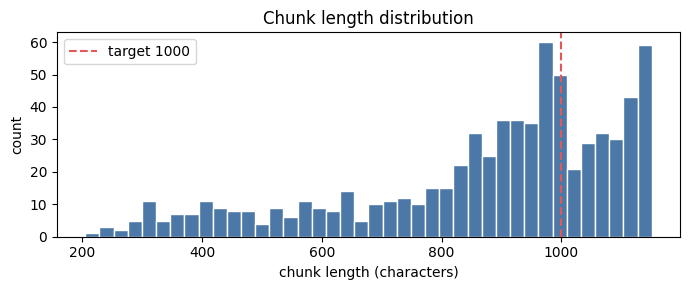

--- sample chunk ---
[CA-p78-0] California p.78

VEHICLE POSITIONING Following Distances Suppose you are on a two-lane road with an oncoming
vehicle approaching and a bicyclist ahead to your right. Instead of driving between the vehicle
and the bicyclist, take one danger at a time. First, slow down and let the oncoming vehicle
pass. Then, when it is safe, move to the left to allow plenty of room (at least 3 feet) to pass
the bicyclist. Persons Who Present Dangers to Drivers Increase your following distance and allow
a bigger space for drivers who may be potentially dangerous. Persons who present dangers are: •
Drivers who cannot see you beca


In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(lengths, bins=40, color="#4C78A8", edgecolor="white")
ax.axvline(CHUNK_SIZE, color="#E45756", ls="--", label=f"target {CHUNK_SIZE}")
ax.set_xlabel("chunk length (characters)"); ax.set_ylabel("count")
ax.set_title("Chunk length distribution"); ax.legend(); plt.tight_layout(); plt.show()

print("--- sample chunk ---")
sample = next(c for c in chunks if "following distance" in c["text"].lower())
print(f"[{sample['chunk_id']}] {sample['state']} p.{sample['page']}\n")
print(textwrap.fill(sample["text"][:600], 96))

## 2.3 Embeddings & Vector Store

`all-MiniLM-L6-v2` produces 384-dimensional embeddings. It is small, fast, and strong on short
question-to-passage matching, which is exactly this workload. Embeddings are **L2-normalised** and the
collection uses **cosine** distance.

Bulk encoding runs on the GPU. At serve time the backend encodes a single short question per request,
which is a few milliseconds on CPU - so the backend deliberately keeps this model on CPU and leaves
the GPU entirely to the LLM.

In [6]:
import chromadb
from sentence_transformers import SentenceTransformer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
embedder = SentenceTransformer(EMBED_MODEL, device=device)
print(f"embedding {len(chunks)} chunks on {device} ...")

vectors = embedder.encode([c["text"] for c in chunks], batch_size=256,
                          normalize_embeddings=True, show_progress_bar=False)
print("embedding matrix:", vectors.shape)

# Bulk encoding is finished, so hand the GPU back. On a 6 GB card, holding this
# model resident leaves too little room for Ollama to load qwen2.5:7b, and section
# 2.4 fails with a ResponseError. Retrieval only ever encodes one short question,
# which is milliseconds on CPU - the same trade-off backend/services/retrieval.py makes.
embedder.to("cpu")
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free, total = torch.cuda.mem_get_info()
    print(f"GPU handed back to the LLM: {free/1e9:.1f} / {total/1e9:.1f} GB free")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

embedding 726 chunks on cuda ...


embedding matrix: (726, 384)
GPU handed back to the LLM: 5.3 / 6.4 GB free


In [7]:
def reset_store():
    # Clear the store's *contents*, not the folder itself: when the project lives in a
    # OneDrive-synced path, rmtree on the directory raises WinError 5.
    STORE_DIR.mkdir(parents=True, exist_ok=True)
    for p in STORE_DIR.iterdir():
        shutil.rmtree(p, ignore_errors=True) if p.is_dir() else p.unlink()

reset_store()
client = chromadb.PersistentClient(path=str(STORE_DIR))
collection = client.create_collection(COLLECTION, metadata={"hnsw:space": "cosine"})
collection.add(
    ids=[c["chunk_id"] for c in chunks],
    embeddings=vectors.tolist(),
    documents=[c["text"] for c in chunks],
    metadatas=[{"state": c["state"], "source_file": c["source_file"], "page": c["page"]}
               for c in chunks],
)
store_mb = sum(f.stat().st_size for f in STORE_DIR.rglob("*") if f.is_file()) / 1e6
print(f"persisted {collection.count()} chunks to {rel(STORE_DIR)}  ({store_mb:.1f} MB on disk)")

persisted 726 chunks to data/vector_store  (8.9 MB on disk)


## 2.4 Retrieval & Prompting

`retrieve()` embeds the question and returns the top-k chunks, optionally filtered to a single state.

**The state filter matters.** The three handbooks describe genuinely different law - the BAC threshold
for drivers under 21, when you may turn right on red, school-bus stopping rules. Without a filter,
a question about one state can be answered from another state's page. Section 2.6 quantifies this.

In [8]:
def retrieve(question, state=None, k=TOP_K):
    qv = embedder.encode([question], normalize_embeddings=True).tolist()
    res = collection.query(query_embeddings=qv, n_results=k,
                           where={"state": state} if state else None)
    return [{"text": d, "state": m["state"], "page": m["page"],
             "source_file": m["source_file"], "distance": dist}
            for d, m, dist in zip(res["documents"][0], res["metadatas"][0], res["distances"][0])]

SAMPLE_QUESTIONS = [
    ("What is the blood alcohol concentration limit for a driver 21 or older?", "California"),
    ("What is the BAC limit for drivers under 21?",                            "California"),
    ("How many seconds of following distance at speeds under 35 MPH?",         "Virginia"),
    ("What must you do when a school bus flashes its red lights?",             "New York"),
    ("What does a solid red traffic signal mean?",                             "California"),
    ("How much space must you give a bicyclist when passing?",                 "California"),
    ("When may you pass another vehicle on the right?",                        "New York"),
    ("How close to a school must you slow down when children are present?",    "California"),
    ("What should you do when you see a yellow traffic signal light?",         "California"),
    ("How do you measure a safe following distance?",                          "Virginia"),
    ("What are the rules for driving in a roundabout?",                        None),
    ("What should you do if your vehicle starts to skid?",                     None),
]

for q, state in SAMPLE_QUESTIONS:
    hits = retrieve(q, state, k=2)
    print(f"\nQ: {q}   [state={state or 'ANY'}]")
    for h in hits:
        preview = " ".join(h["text"][:130].split())
        print(f"   ({h['state']} p.{h['page']} dist={h['distance']:.3f}) {preview}...")


Q: What is the blood alcohol concentration limit for a driver 21 or older?   [state=California]
   (California p.114 dist=0.380) Blood Alcohol Concentration (BAC) Limits It is illegal for any person to operate a vehicle with a BAC of: • 0.08% or higher, if th...
   (California p.115 dist=0.414) If you refuse to submit to the required blood and/or urine test(s), your driving privilege may be suspended because of your refusa...

Q: What is the BAC limit for drivers under 21?   [state=California]
   (California p.114 dist=0.416) Blood Alcohol Concentration (BAC) Limits It is illegal for any person to operate a vehicle with a BAC of: • 0.08% or higher, if th...
   (California p.27 dist=0.430) -800-777-0133. Send the DL 33 to your out-of-state secondary school and ask them to complete and return it to you. Out-Of-State Mi...

Q: How many seconds of following distance at speeds under 35 MPH?   [state=Virginia]
   (Virginia p.21 dist=0.544) Maintaining a Space Cushion Space around your vehic


Q: How much space must you give a bicyclist when passing?   [state=California]
   (California p.90 dist=0.387) ning to your original lane while leaving room between your vehicle and the bicyclist. When you cannot change lanes to pass a bicyc...
   (California p.89 dist=0.438) sible from a distance of 500 feet. • A white or yellow reflector on each pedal or the bicyclist’s shoes or ankles visible from a d...

Q: When may you pass another vehicle on the right?   [state=New York]
   (New York p.39 dist=0.284) hat you can see at least several feet of pavement between your vehicle and the one you passed. Then return to the right lane. HOW...
   (New York p.39 dist=0.336) pace to ride. When overtaking a bicyclist from behind, the law requires you to pass on the left at a safe distance until the bicyc...

Q: How close to a school must you slow down when children are present?   [state=California]
   (California p.50 dist=0.369) Slow down and pass safely, and pass only at a safe distance (3 fe


Q: How do you measure a safe following distance?   [state=Virginia]
   (Virginia p.21 dist=0.543) eways, curves, hills and different road conditions. Watch for other vehicles, especially trucks, oversized and slowmoving farm veh...
   (Virginia p.21 dist=0.577) Maintaining a Space Cushion Space around your vehicle gives you distance to react in emergencies and avoid a crash. Create a space...

Q: What are the rules for driving in a roundabout?   [state=ANY]
   (New York p.50 dist=0.283) ROUNDABOUTS What is a roundabout? The modern roundabout is a type of circular intersection with yield control of entering traffic...
   (New York p.50 dist=0.302) esigned so that the speed of all vehicles is restricted to 30 mph (50 km/h) or less within the roundabout. How to Navigate a Round...

Q: What should you do if your vehicle starts to skid?   [state=ANY]
   (California p.105 dist=0.304) going downhill. If you start to skid: • Ease off the accelerator (gas) pedal. • Stop braking. • Turn the ste

### Prompt template and citation grounding

The context blocks are **numbered**, and each carries its state and page. The system prompt requires
the model to (a) answer only from those blocks, (b) cite inline as `[1]`, and (c) emit an exact
refusal string when the context does not contain the answer.

That refusal string is the project's grounding proof: an assistant that answers "who won the World
Cup" from its own weights is not grounded, and section 2.6 tests this directly.

In [9]:
import ollama

REFUSAL = "I could not find this in the handbook."

SYSTEM_PROMPT = (
    "You are a driving-rules assistant. You answer ONLY from the numbered context blocks "
    "supplied by the user. Those blocks are excerpts from official US state driver handbooks.\n\n"
    "Rules:\n"
    "1. Use ONLY facts stated in the context. Never use outside knowledge.\n"
    "2. Cite the block you used inline, like [1] or [2], immediately after the claim it supports.\n"
    f"3. If the context does not contain the answer, reply with exactly: {REFUSAL}\n"
    "4. If the question is about a specific state, prefer blocks from that state's handbook.\n"
    "5. Be concise - two or three sentences unless the rule is a list."
)

def build_prompt(question, hits):
    blocks = "\n\n".join(
        f"[{i}] ({h['state']} handbook, p.{h['page']})\n{h['text']}"
        for i, h in enumerate(hits, 1))
    return f"CONTEXT:\n{blocks}\n\nQUESTION: {question}"

def format_sources(hits):
    seen, out = set(), []
    for h in hits:
        key = (h["source_file"], h["page"])
        if key not in seen:
            seen.add(key)
            out.append(f"{h['source_file']} - p.{h['page']} ({h['state']})")
    return out

def cited_sources(hits, text):
    # Cite only the blocks the answer actually used. Returning all k retrieved chunks
    # would overstate the grounding - the model typically uses one or two of the five.
    idx = sorted({int(n) for n in re.findall(r"\[(\d+)\]", text)})
    used = [hits[i - 1] for i in idx if 1 <= i <= len(hits)]
    return format_sources(used or hits)

def answer(question, state=None, k=TOP_K):
    hits = retrieve(question, state, k)
    if not hits:
        return {"answer": REFUSAL, "sources": [], "hits": []}
    resp = ollama.chat(model=LLM_MODEL, options={"temperature": 0.0, "num_predict": 400},
                       messages=[{"role": "system", "content": SYSTEM_PROMPT},
                                 {"role": "user",   "content": build_prompt(question, hits)}])
    text = resp["message"]["content"].strip()
    grounded = REFUSAL.lower() not in text.lower()
    return {"answer": text,
            "sources": cited_sources(hits, text) if grounded else [],
            "hits": hits}

demo = answer("What is the BAC limit for drivers under 21?", state="California")
print(textwrap.fill(demo["answer"], 96))
print("\nSOURCES:")
for s in demo["sources"]:
    print("  -", s)

The BAC limit for drivers under 21 years old is 0.01% [1].

SOURCES:
  - ca_driver_handbook.pdf - p.114 (California)


In [10]:
# A question the handbooks do not cover -- the assistant must refuse rather than invent.
oos = answer("Who won the 2022 FIFA World Cup?")
print("OUT-OF-SCOPE ->", oos["answer"])
print("sources:", oos["sources"])

OUT-OF-SCOPE -> I could not find this in the handbook.
sources: []


## 2.5 Vision Component (Extended Track)

A fine-tuned `yolo11n` identifies a road sign in an uploaded photo. The predicted class is mapped to a
natural-language lookup, which is then run through the **same** retrieval + generation path as a typed
question - so an image query is answered from the handbook, with citations, exactly like text.

**Training runs in Colab** (`notebooks/yolo_training_colab.ipynb`) on a free T4, because fine-tuning is
the only genuinely GPU-bound step. This notebook *loads* the resulting weights. The training cell is
kept below but guarded by `TRAIN_YOLO`, so **Restart & Run All still passes** without a GPU or the
image dataset present.

In [11]:
from ultralytics import YOLO

WEIGHTS = BACKEND_DIR / "models" / "signs_yolo.pt"
DATA_YAML = ROOT / "data" / "signs" / "data.yaml"
TRAIN_YOLO = False   # set True only to retrain; see notebooks/yolo_training_colab.ipynb

if TRAIN_YOLO:
    assert DATA_YAML.exists(), "download the sign dataset first - see README"
    result = YOLO("yolo11n.pt").train(data=str(DATA_YAML), imgsz=640, epochs=60, batch=32)
    shutil.copy(Path(result.save_dir) / "weights" / "best.pt", WEIGHTS)

yolo = YOLO(str(WEIGHTS)) if WEIGHTS.exists() else None
print("YOLO weights:", rel(WEIGHTS) if yolo else "NOT PRESENT - vision cells degrade gracefully")
if yolo:
    print("classes:", yolo.names)

YOLO weights: backend/models/signs_yolo.pt
classes: {0: 'crosswalk', 1: 'speedlimit', 2: 'stop'}


### Fusing detection output into the RAG prompt

Each sign class maps to the phrasing a handbook actually uses, so retrieval lands on the rule rather
than on a passing mention of the sign.

**An honest limitation:** the `speedlimit` class tells us a speed-limit sign is present, not which
number it displays. The lookup is therefore about speed-limit *rules*, not a specific posted value.
Reading the digits would require a second OCR stage, which is out of scope here.

In [12]:
CLASS_TO_QUERY = {
    "stop":         "stop sign rules: where to stop and when to proceed",
    "speedlimit":   "posted speed limit rules and maximum speed limits",
    "crosswalk":    "pedestrian crosswalk rules and yielding right of way to pedestrians",
    "trafficlight": "traffic signal lights: red, yellow and green meanings",
}

def answer_from_image(image_path, state=None, conf=0.25):
    if yolo is None:
        return {"answer": "Vision model not available.", "sources": [], "detections": []}
    result = yolo.predict(image_path, conf=conf, verbose=False)[0]
    detections = [{"label": yolo.names[int(b.cls)], "confidence": round(float(b.conf), 3),
                   "bbox": [round(v) for v in b.xyxy[0].tolist()]} for b in result.boxes]
    if not detections:
        return {"answer": "No road sign was detected in this image.",
                "sources": [], "detections": []}
    top = max(detections, key=lambda d: d["confidence"])
    query = CLASS_TO_QUERY.get(top["label"], f"{top['label']} sign rules")
    out = answer(f"A {top['label'].replace('_', ' ')} sign was detected in a photo. {query}", state)
    out["detections"] = detections
    return out

print("class -> retrieval query mapping:")
for k, v in CLASS_TO_QUERY.items():
    covered = "" if yolo is None or k in yolo.names.values() else "   (not in these weights)"
    print(f"  {k:13s} -> {v}{covered}")

class -> retrieval query mapping:
  stop          -> stop sign rules: where to stop and when to proceed
  speedlimit    -> posted speed limit rules and maximum speed limits
  crosswalk     -> pedestrian crosswalk rules and yielding right of way to pedestrians
  trafficlight  -> traffic signal lights: red, yellow and green meanings   (not in these weights)


### Running inference end to end

Two sample images are committed in `docs/sample_signs/`, so this section runs without the
(gitignored) training dataset. They are US **MUTCD** sign faces - works of the US federal government,
so public domain - retrieved via Wikimedia Commons and composited onto a plain background.

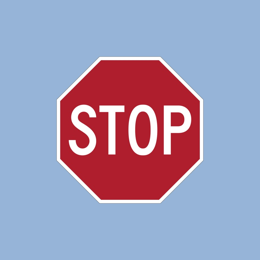

--- stop_sign.jpg ---
  detected   : stop  confidence 0.963  bbox [209, 184, 717, 713]
  answer     : According to the context, you must make a full "STOP" whenever you see an 8-sided
               red STOP sign [2]. Stop at the white limit line (a wide white line painted on the
               street) or before entering the crosswalk. If a limit line or crosswalk is not
               painted on the street, stop before entering the intersection. Check traffic in
               all directions before proceeding [2].
  source     : ca_driver_handbook.pdf - p.43 (California)



In [13]:
from IPython.display import display
from PIL import Image

SAMPLE_DIR = ROOT / "docs" / "sample_signs"

def show_detection(path, state=None):
    result = answer_from_image(path, state=state)
    print(f"--- {Path(path).name} ---")
    if not result["detections"]:
        print("  detections : none")
    for d in result["detections"]:
        print(f"  detected   : {d['label']}  confidence {d['confidence']:.3f}  bbox {d['bbox']}")
    print(textwrap.fill("  answer     : " + " ".join(result["answer"].split()), 96,
                        subsequent_indent=" " * 15))
    for s in result.get("sources", []):
        print(f"  source     : {s}")
    print()
    return result

if yolo is not None:
    display(Image.open(SAMPLE_DIR / "stop_sign.jpg").resize((260, 260)))
    hit = show_detection(SAMPLE_DIR / "stop_sign.jpg", state="California")
else:
    print("weights absent - skipping (see notebooks/yolo_training_colab.ipynb)")

### A limitation worth stating plainly

The second sample is a **speed-limit sign, a class these weights were trained on** - yet it is not
detected. The reason is a domain gap rather than a bug: every training image was a *photograph* of a
sign in a real scene, with perspective, shadow, motion blur and JPEG noise. A crisp flat vector
rendering sits outside that distribution.

The stop sign survives the same treatment (0.96) because its silhouette and colour are so distinctive
that shape alone carries it; a white rectangle of digits has far less to go on.

Practical consequence for the demo and the API: feed it **photographs**. Closing this gap properly
would mean adding rendered signs to the training set, not changing any code here.

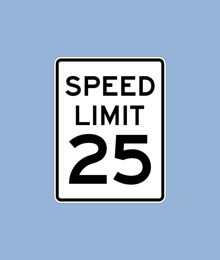

--- speed_limit_render.jpg ---
  detections : none
  answer     : No road sign was detected in this image.

Note: the API returns a plain 'no sign detected' message here rather than an error,
so the frontend can prompt for a better photo instead of failing.


In [14]:
if yolo is not None:
    display(Image.open(SAMPLE_DIR / "speed_limit_render.jpg").resize((220, 260)))
    miss = show_detection(SAMPLE_DIR / "speed_limit_render.jpg", state="California")
    print("Note: the API returns a plain 'no sign detected' message here rather than an error,")
    print("so the frontend can prompt for a better photo instead of failing.")

## 2.6 Evaluation

15 test questions in four groups:

1. **Factual lookups** with a verifiable value (BAC thresholds, following distance, passing clearance).
2. **Procedural** rules (signal meanings, school buses, passing on the right).
3. **Cross-state traps** - the same question asked with and without the state filter. The handbooks
   genuinely disagree, so an unfiltered answer can be confidently wrong.
4. **Out-of-scope** questions the handbooks do not cover. The assistant must refuse.

Two metrics are computed automatically:

- **Retrieval hit-rate** - did the top-k contain the page that actually holds the answer?
- **Groundedness** - did the assistant answer from context when it should, and refuse when it should?

`correct` is checked by requiring an expected keyword in the answer, so the table is reproducible
rather than hand-graded.

In [15]:
# expect_keywords: answer must contain at least one. gold_pages: retrieval must surface one of these.
EVAL = [
    # --- 1. factual lookups ---
    dict(q="What is the blood alcohol concentration limit for a driver 21 or older?",
         state="California", group="factual", expect_keywords=["0.08"], gold_pages=[114]),
    dict(q="What is the BAC limit for drivers under 21?",
         state="California", group="factual", expect_keywords=["0.01"], gold_pages=[114]),
    dict(q="How many seconds of following distance should you keep under 35 MPH?",
         state="Virginia", group="factual", expect_keywords=["2 second", "two second"], gold_pages=[21]),
    # The 3-foot rule appears twice in the CA handbook: briefly on p.50 and in full on
    # p.90. Both count as gold - labelling only p.50 would score a correct hit as a miss.
    dict(q="How much clearance must you give a bicyclist when passing?",
         state="California", group="factual", expect_keywords=["3 feet", "three feet"],
         gold_pages=[50, 90]),
    dict(q="How close to a school must you slow down when children are outside?",
         state="California", group="factual", expect_keywords=["500", "1,000", "1000"], gold_pages=[50]),

    # --- 2. procedural ---
    dict(q="What must you do when a school bus flashes its red lights?",
         state="New York", group="procedural", expect_keywords=["stop"], gold_pages=[40]),
    dict(q="What does a solid red traffic signal light mean?",
         state="California", group="procedural", expect_keywords=["stop"], gold_pages=[41]),
    dict(q="What should you do when you see a yellow traffic signal light?",
         state="California", group="procedural", expect_keywords=["stop", "caution"], gold_pages=[41]),
    dict(q="When may you pass another vehicle on the right?",
         state="New York", group="procedural", expect_keywords=["lane", "right"], gold_pages=[40]),
    dict(q="How do you measure a safe following distance?",
         state="Virginia", group="procedural", expect_keywords=["second", "fixed"], gold_pages=[21]),

    # --- 3. cross-state traps (same question, filter on vs off) ---
    dict(q="What is the BAC limit for drivers under 21?",
         state=None, group="cross-state (no filter)", expect_keywords=["0.01"], gold_pages=[114]),
    dict(q="What must you do when a school bus flashes its red lights?",
         state="Virginia", group="cross-state (filtered)", expect_keywords=["stop"], gold_pages=None),

    # --- 4. out-of-scope: must refuse ---
    dict(q="Who won the 2022 FIFA World Cup?",
         state=None, group="out-of-scope", expect_refusal=True),
    dict(q="What is the capital of France?",
         state=None, group="out-of-scope", expect_refusal=True),
    dict(q="How do I change the oil in my car?",
         state=None, group="out-of-scope", expect_refusal=True),
]
print(f"{len(EVAL)} evaluation questions across {len(set(e['group'] for e in EVAL))} groups")

15 evaluation questions across 5 groups


In [16]:
rows = []
for e in EVAL:
    res = answer(e["q"], e.get("state"))
    ans, hits = res["answer"], res["hits"]
    refused = REFUSAL.lower() in ans.lower()
    expect_refusal = e.get("expect_refusal", False)

    if expect_refusal:
        hit = None
        grounded = refused          # refusing IS the grounded behaviour here
        correct = refused
    else:
        gold = e.get("gold_pages")
        hit = None if gold is None else any(h["page"] in gold for h in hits)
        grounded = (not refused) and bool(re.search(r"\[\d+\]", ans))
        correct = (not refused) and any(k.lower() in ans.lower() for k in e["expect_keywords"])

    rows.append({
        "group": e["group"],
        "question": e["q"][:52] + ("..." if len(e["q"]) > 52 else ""),
        "state": e.get("state") or "ANY",
        "retrieved_source": (f"{hits[0]['state']} p.{hits[0]['page']}" if hits else "-"),
        "answer": " ".join(ans.split())[:70] + "...",
        "retrieval_hit": {True: "Y", False: "N", None: "-"}[hit],
        "grounded": "Y" if grounded else "N",
        "correct": "Y" if correct else "N",
    })

df_eval = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 74, "display.width", 250)
df_eval

,group,question,state,retrieved_source,answer,retrieval_hit,grounded,correct
0,factual,What is the blood alcohol concentration limit for a ...,California,California p.114,The blood alcohol concentration (BAC) limit for a driver 21 years old ...,Y,Y,Y
1,factual,What is the BAC limit for drivers under 21?,California,California p.114,The BAC limit for drivers under 21 years old is 0.01% [1]....,Y,Y,Y
2,factual,How many seconds of following distance should you ke...,Virginia,Virginia p.21,"Under 35 MPH, you should maintain a following distance of 2 seconds [1...",Y,Y,Y
3,factual,How much clearance must you give a bicyclist when pa...,California,California p.90,"When passing a bicyclist, you must allow at least 3 feet between your ...",Y,Y,Y
4,factual,How close to a school must you slow down when childr...,California,California p.50,"When driving within 500 to 1,000 feet of a school while children are o...",Y,Y,Y
5,procedural,What must you do when a school bus flashes its red l...,New York,New York p.40,"You must stop before you reach the bus, at least 20 feet (6 m) away fr...",Y,Y,Y
6,procedural,What does a solid red traffic signal light mean?,California,California p.41,"A solid red traffic signal light means ""STOP."" You can make a right tu...",Y,Y,Y
7,procedural,What should you do when you see a yellow traffic sig...,California,California p.41,"When you see a yellow traffic signal light, stop if you can do so safe...",Y,Y,Y
8,procedural,When may you pass another vehicle on the right?,New York,New York p.39,"You can pass another vehicle on the right under specific conditions, s...",Y,Y,Y
9,procedural,How do you measure a safe following distance?,Virginia,Virginia p.21,"To measure a safe following distance, glance at a fixed object as the ...",Y,Y,Y


In [17]:
scored = [r for r in rows if r["retrieval_hit"] != "-"]
hit_rate   = sum(r["retrieval_hit"] == "Y" for r in scored) / max(len(scored), 1)
grounded   = sum(r["grounded"] == "Y" for r in rows) / len(rows)
correct    = sum(r["correct"]  == "Y" for r in rows) / len(rows)
refusals   = [r for r in rows if r["group"] == "out-of-scope"]
refuse_ok  = sum(r["correct"] == "Y" for r in refusals) / max(len(refusals), 1)

print(f"retrieval hit-rate (gold page in top-{TOP_K}) : {hit_rate:6.0%}  ({len(scored)} scored)")
print(f"groundedness (answered from context / refused): {grounded:6.0%}")
print(f"answer correctness (expected value present)   : {correct:6.0%}")
print(f"out-of-scope refusal rate                     : {refuse_ok:6.0%}  ({len(refusals)} questions)")
print("\nper-group correctness:")
print(df_eval.groupby("group")["correct"].apply(lambda s: f"{(s == 'Y').mean():.0%}").to_string())

retrieval hit-rate (gold page in top-5) :   100%  (11 scored)
groundedness (answered from context / refused):   100%
answer correctness (expected value present)   :   100%
out-of-scope refusal rate                     :   100%  (3 questions)

per-group correctness:
group
cross-state (filtered)     100%
cross-state (no filter)    100%
factual                    100%
out-of-scope               100%
procedural                 100%


### Measuring what the state filter is actually worth

The same question is asked with the filter off and on, sweeping `k`. This isolates the
filter's real effect: it does not just change the answer, it changes **how much of the
context budget is spent on the wrong state's pages**.

In [18]:
q_trap = "What is the BAC limit for drivers under 21?"
print(f"{'k':>2}  {'filter':<12} {'retrieved ranks':<34} {'correct':<8} answer")
print("-" * 110)
for k in (2, 3, 5):
    for state in (None, "California"):
        hits = retrieve(q_trap, state, k=k)
        res = answer(q_trap, state, k=k)
        ranks = ", ".join(f"{h['state'][:2]}p{h['page']}" for h in hits)
        correct = "0.01" in res["answer"]
        print(f"{k:>2}  {state or 'NONE':<12} {ranks:<34} {str(correct):<8} "
              f"{' '.join(res['answer'].split())[:52]}")

 k  filter       retrieved ranks                    correct  answer
--------------------------------------------------------------------------------------------------------------


 2  NONE         Nep6, Nep6                         False    I could not find this in the handbook.


 2  California   Cap114, Cap27                      True     The BAC limit for drivers under 21 is 0.01% or highe


 3  NONE         Nep6, Nep6, Cap114                 True     The BAC limit for drivers under 21 years old is 0.01


 3  California   Cap114, Cap27, Cap36               True     The BAC limit for drivers under 21 years old in Cali


 5  NONE         Nep6, Nep6, Cap114, Cap27, Cap36   True     The BAC limit for drivers under 21 is 0.01% or highe


 5  California   Cap114, Cap27, Cap36, Cap118, Cap115 True     The BAC limit for drivers under 21 years old is 0.01


### Failure cases observed, and what was done about them

**1. Cross-state contamination - the headline failure.** Asked "what is the BAC limit for drivers
under 21?" with no filter, the top two chunks are both *New York* p.6 - a passage that contains
neither the string "BAC" nor any threshold. The *California* page that actually carries the
0.01% / 0.08% table is pushed down to rank 3.

The k-sweep above shows what that costs, and the result is more interesting than expected:

| k | filter | retrieved | outcome |
|---|---|---|---|
| 2 | off | NY p.6, NY p.6 | **refuses** - the answer never enters the context |
| 2 | on  | CA p.114, CA p.27 | correct |
| 3 | off | NY p.6, NY p.6, CA p.114 | correct, citing `[3]` |
| 5 | off | NY p.6 x2, CA p.114, ... | correct, citing `[3]` |

So the filter's real job is **not** to stop the model answering from the wrong state - it is to stop
the wrong state's pages consuming the context budget. At `k=5` the correct page still squeezes in and
the answer survives; at `k=2` it does not, and the assistant refuses. Notably it **refuses rather than
inventing a number**, which is itself evidence that the grounding instruction is doing its job: the
failure is visible instead of silent.

**Mitigation:** `state` is stored as chunk metadata and passed as a Chroma `where` filter; the UI
exposes it as a selector and warns when it is set to "All states". The filter also makes the answer
cheaper and more reliable - with it on, the right page is rank 1 rather than rank 3.

**2. Answering from model knowledge instead of context.** Early prompt drafts let the model answer
general-knowledge questions from its own weights. **Mitigation:** the system prompt pins it to the
numbered blocks, requires inline `[n]` citations, and specifies an exact refusal string; `temperature`
is 0. The out-of-scope group verifies this, and the groundedness metric counts an answer as grounded
only if it either cites a block or refuses.

**3. Table-of-contents and artwork pages polluting retrieval.** The first build indexed contents pages,
which extract as long runs of dot leaders. They matched many queries weakly and crowded out real
prose. **Mitigation:** `is_toc_like` drops those pages at load time and `is_prose` drops residual
fragments after chunking - together removing 21 pages and 31 chunks.

**4. Column interleaving on mixed-layout pages.** Where a callout box sits beside body text,
extraction can splice the two, producing a chunk with a sentence from each. This is inherent to
flattening a 2-D layout. It degrades a small number of chunks rather than failing loudly; the 150-char
overlap limits the damage because the same rule usually also appears intact in a neighbouring chunk.

**5. Thresholds split across a chunk boundary.** The Virginia following-distance rule is a small table
(2 / 3 / 4 seconds against speed bands) that a hard cut can separate from its speeds. The 150-character
overlap was chosen specifically to carry that binding across the boundary.

## 2.7 Export

The backend loads these artifacts directly at startup - it never re-chunks or re-embeds at request
time. `config.json` records the build parameters so the backend uses the same embedding model and
collection name the store was built with.

In [19]:
config = {
    "embedding_model": EMBED_MODEL,
    "collection_name": COLLECTION,
    "llm_model": LLM_MODEL,
    "chunk_size": CHUNK_SIZE,
    "chunk_overlap": CHUNK_OVERLAP,
    "chunk_count": collection.count(),
    "top_k": TOP_K,
    "states": sorted(HANDBOOKS),
    "sources": {s: title for s, (_, title) in HANDBOOKS.items()},
    "refusal_string": REFUSAL,
    "built_at": pd.Timestamp.utcnow().isoformat(),
}
(STORE_DIR / "config.json").write_text(json.dumps(config, indent=2))
print(json.dumps(config, indent=2))

{
  "embedding_model": "all-MiniLM-L6-v2",
  "collection_name": "driver_handbooks",
  "llm_model": "qwen2.5:7b-instruct",
  "chunk_size": 1000,
  "chunk_overlap": 150,
  "chunk_count": 726,
  "top_k": 5,
  "states": [
    "California",
    "New York",
    "Virginia"
  ],
  "sources": {
    "California": "California Driver's Handbook (DL 600)",
    "New York": "New York State Driver's Manual (MV-21)",
    "Virginia": "Virginia Driver's Manual (DMV 39)"
  },
  "refusal_string": "I could not find this in the handbook.",
  "built_at": "2026-09-13T23:59:59.166843+00:00"
}


In [20]:
# Mirror the persisted store into the backend so `uvicorn` can load it with no extra steps.
# dirs_exist_ok / ignore_errors matter here: on a OneDrive-synced path the sync client can
# hold a directory handle, so a delete may silently fail and leave the folder behind.
target = BACKEND_DIR / "data" / "vector_store"
target.mkdir(parents=True, exist_ok=True)
for p in target.iterdir():
    if p.is_dir():
        shutil.rmtree(p, ignore_errors=True)
    else:
        p.unlink(missing_ok=True)

for item in STORE_DIR.iterdir():
    if item.is_dir():
        shutil.copytree(item, target / item.name, dirs_exist_ok=True)
    else:
        shutil.copy2(item, target)

size_mb = sum(f.stat().st_size for f in target.rglob("*") if f.is_file()) / 1e6
print(f"vector store exported -> {rel(target)}  ({size_mb:.1f} MB, {collection.count()} chunks)")
print("\nBackend is ready:  cd backend && uvicorn app.main:app --reload")

vector store exported -> backend/data/vector_store  (9.1 MB, 726 chunks)

Backend is ready:  cd backend && uvicorn app.main:app --reload
